In [ ]:
import pandas as pd
import yfinance as yf
from pandas_datareader import data as pdr
import numpy as np
from scipy.optimize import linprog, minimize

# --- Config ---
START_DATE = "2004-01-01"
END_DATE = "2024-12-31"
node = 10

# --- Data Fetch ---
def fetch_yahoo_close(ticker, name, interval='1mo'):
    df = yf.download(ticker, start=START_DATE, end=END_DATE, interval=interval, progress=False)
    df = df[['Close']]
    df.columns = [name]
    return df

def fetch_fred_series(code, name):
    df = pdr.DataReader(code, 'fred', start=START_DATE, end=END_DATE)
    return df.rename(columns={code: name})

# --- Fetching Data ---
sp500 = fetch_yahoo_close('^GSPC', 'SP500_Close')
goog  = fetch_yahoo_close('GOOG', 'GOOG_Close')
aapl  = fetch_yahoo_close('AAPL', 'AAPL_Close')
msft  = fetch_yahoo_close('MSFT', 'MSFT_Close')
tbill = fetch_fred_series('DTB3', 'TBill_Rate')

# --- Merge ---
market_data = sp500.join([goog, aapl, msft, tbill], how='outer')
market_data = market_data.resample('M').last()
market_data = market_data.dropna()
market_data.columns = market_data.columns.str.strip()

# --- Scenario Tree Setup ---
def build_arbitrage_free_tree(df, branching_structure, max_attempts=100):
    returns_df = df.pct_change().dropna()
    tree = {
        'nodes': {},
        'structure': branching_structure,
        'num_stages': len(branching_structure) + 1,
        'num_assets': len(df.columns)
    }
    tree['nodes'][0] = {'stage': 0, 'parent': None, 'children': [], 'probability': 1.0, 'returns': None}
    node_counter = 1

    for stage in range(1, tree['num_stages']):
        prev_nodes = [n for n, node in tree['nodes'].items() if node['stage'] == stage - 1]
        for parent_id in prev_nodes:
            parent = tree['nodes'][parent_id]
            for _ in range(max_attempts):
                sampled = returns_df.sample(branching_structure[stage - 1], replace=True).values
                if check_no_arbitrage(sampled, riskfree_idx=len(df.columns)-1):
                    for i, r in enumerate(sampled):
                        tree['nodes'][node_counter] = {
                            'stage': stage,
                            'parent': parent_id,
                            'children': [],
                            'probability': parent['probability'] / branching_structure[stage - 1],
                            'returns': r
                        }
                        parent['children'].append(node_counter)
                        node_counter += 1
                    break
            else:
                raise RuntimeError(f"Failed to find arbitrage-free returns for node {parent_id}")

    tree['nodes'][0]['full_prob'] = 1.0
    for nid, node in tree['nodes'].items():
        if node['parent'] is not None:
            parent = tree['nodes'][node['parent']]
            node['full_prob'] = parent['full_prob'] * (node['probability'] / parent['probability'])

    return tree

def check_no_arbitrage(returns, riskfree_idx=-1):
    num_scenarios, num_assets = returns.shape
    A_eq = [[1.0]*num_scenarios]
    b_eq = [1.0]
    for i in range(num_assets):
        if i == riskfree_idx:
            continue
        A_eq.append([(1 + returns[j, i]) / (1 + returns[j, riskfree_idx]) for j in range(num_scenarios)])
        b_eq.append(1.0)
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(1e-10, None)] * num_scenarios
    return linprog(np.ones(num_scenarios), A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs').success

# --- Build Tree ---
asset_cols = ['SP500_Close', 'GOOG_Close', 'AAPL_Close', 'MSFT_Close', 'TBill_Rate']
df_assets = market_data[asset_cols]
tree = build_arbitrage_free_tree(df_assets, [node, node, node])
risk_free_rates = df_assets['TBill_Rate'].values[:tree['num_stages']-1] / 100

# --- MEMM Risk-Neutral Probabilities ---
#def compute_minimal_entropy_measure(returns, p, rf_rate):
def compute_minimal_entropy_measure(returns, p, rf_rate):
    R = 1 + rf_rate

    # Not enough scenarios to satisfy constraints
    if returns.shape[0] < returns.shape[1] + 1:
        print(f"⚠️ Skipping MEMM: only {returns.shape[0]} scenarios for {returns.shape[1]+1} constraints")
        return p

    def kl(q):
        eps = 1e-12
        return np.sum(q * np.log(np.clip(q / (p + eps), eps, None)))

    # Slightly randomize q0 to avoid local minima
    q0 = np.clip(p + np.random.uniform(-1e-3, 1e-3, size=p.shape), 1e-10, 1)
    q0 /= q0.sum()

    # Constraints: sum(q) = 1 and E^q[(1 + R_i)] = R
    cons = [{'type': 'eq', 'fun': lambda q: np.sum(q) - 1.0}]
    for i in range(returns.shape[1]):
        cons.append({'type': 'eq', 'fun': lambda q, i=i: np.dot(q, 1 + returns[:, i]) - R})

    # Optimization with extended max iterations
    result = minimize(
        kl,
        q0,
        bounds=[(1e-10, 1.0)] * len(p),
        constraints=cons,
        method='SLSQP',
        options={'maxiter': 2000, 'disp': False}
    )

    if not result.success:
        print(f"⚠️ MEMM failed: {result.message}")
        return p

    return result.x


def calculate_risk_neutral_measure(tree, risk_free_rates):

    for stage in range(1, tree['num_stages']):
        print(f"\n📦 Stage {stage}")
        parent_nodes = [nid for nid, node in tree['nodes'].items() if node['stage'] == stage - 1]

        for pid in parent_nodes:
            parent = tree['nodes'][pid]
            children = parent['children']
            if not children or any(tree['nodes'][cid]['returns'] is None for cid in children):
                print(f"⛔ Skipping parent {pid} — No children or missing returns.")
                continue

            returns = np.array([tree['nodes'][cid]['returns'] for cid in children])
            real_world_probs = np.array([
                tree['nodes'][cid]['full_prob'] / parent['full_prob']
                for cid in children
            ])

            rn_probs = compute_minimal_entropy_measure(
                returns,
                real_world_probs,
                risk_free_rates[stage - 1]
            )

            for i, cid in enumerate(children):
                tree['nodes'][cid]['risk_neutral_prob'] = rn_probs[i]

            print(f"✅ MEMM computed for parent {pid} with {len(children)} children.")

    return tree


tree = calculate_risk_neutral_measure(tree, risk_free_rates)
from collections import defaultdict

# Group risk-neutral probabilities by stage
stagewise_risk_neutral_probs = defaultdict(list)

for nid, node in tree['nodes'].items():
    stage = node['stage']
    prob = node.get('risk_neutral_prob')
    if prob is not None:
        stagewise_risk_neutral_probs[stage].append(prob)

# Print one row per stage
print("\n📊 Risk-Neutral Probabilities (per stage):")
for stage in sorted(stagewise_risk_neutral_probs):
    probs = stagewise_risk_neutral_probs[stage]
    print(f"Stage {stage}: {np.round(probs, 4)}")

# --- Initial Prices for Each Asset ---
initial_prices = {
    'SP500_Close': market_data['SP500_Close'].iloc[-1],
    'GOOG_Close':  market_data['GOOG_Close'].iloc[-1],
    'AAPL_Close':  market_data['AAPL_Close'].iloc[-1],
    'MSFT_Close':  market_data['MSFT_Close'].iloc[-1],
}

# --- Map asset name to index in the tree data ---
asset_indices = {name: idx for idx, name in enumerate(asset_cols)}

# --- Define one call and one put option per asset ---
class EuropeanOption:
    def __init__(self, strike, maturity_stage, option_type='call', asset_index=0):
        self.strike = strike
        self.maturity_stage = maturity_stage
        self.option_type = option_type.lower()
        self.asset_index = asset_index

    def payoff(self, asset_price):
        if self.option_type == 'call':
            return max(asset_price - self.strike, 0)
        elif self.option_type == 'put':
            return max(self.strike - asset_price, 0)
        else:
            raise ValueError("Invalid option type: must be 'call' or 'put'")

# --- Create Options ---
options = []
for asset_name, price in initial_prices.items():
    idx = asset_indices[asset_name]
    options.append(EuropeanOption(strike=price * 1.05, maturity_stage=3, option_type='call', asset_index=idx))
    options.append(EuropeanOption(strike=price * 1.05, maturity_stage=3, option_type='put',  asset_index=idx))

# --- Enrich Tree with Option Prices ---
def get_ancestor_path(tree, node_id):
    path = []
    while node_id is not None:
        path.insert(0, node_id)
        node_id = tree['nodes'][node_id]['parent']
    return path

def enrich_tree_with_option_prices(tree, options, dummy_price):
    for opt_idx, option in enumerate(options):
        # Step 1: Payoffs at maturity
        option_values = {}
        for nid, node in tree['nodes'].items():
            if node['stage'] == option.maturity_stage:
                asset_return = np.prod([
                    1 + tree['nodes'][ancestor]['returns'][option.asset_index]
                    for ancestor in get_ancestor_path(tree, nid)
                    if tree['nodes'][ancestor]['returns'] is not None
                ])
                final_price = initial_prices[asset_cols[option.asset_index]] * asset_return
                option_values[nid] = option.payoff(final_price)

        # Step 2: Backward Recursion
        for stage in reversed(range(option.maturity_stage)):
            for nid, node in tree['nodes'].items():
                if node['stage'] == stage and node['children']:
                    q = np.array([tree['nodes'][cid]['risk_neutral_prob'] for cid in node['children']])
                    v = np.array([option_values.get(cid, 0.0) for cid in node['children']])
                    option_values[nid] = np.dot(q, v)

        # Step 3: Store values in tree
        for nid in tree['nodes']:
            tree['nodes'][nid][f'option_{opt_idx}_value'] = option_values.get(nid, 0.0)

    return tree

# Apply option pricing
tree = enrich_tree_with_option_prices(tree, options, initial_prices['SP500_Close'])

# --- Output Prices at Root Node ---
print("\n📈 Option Prices at Root Node (Stage 0):")
for i, option in enumerate(options):
    asset_name = asset_cols[option.asset_index]
    print(f"Option {i}: {option.option_type.upper()} on {asset_name} | Strike={option.strike:.2f} | "
          f"Maturity Stage={option.maturity_stage} → Value: {tree['nodes'][0][f'option_{i}_value']:.4f}")
# --- Flatten Tree ---
def flatten_tree(tree):
    node_ids = list(tree['nodes'].keys())
    print("node_ids:")
    print(node_ids)
    num_nodes = len(node_ids)
    stage_arr = np.zeros(num_nodes, dtype=int)
    parent_arr = np.full(num_nodes, -1, dtype=int)
    prob_arr = np.zeros(num_nodes)
    full_prob_arr = np.zeros(num_nodes)
    return_arr = [None] * num_nodes
    option_cash = np.zeros(num_nodes)

    node_id_to_idx = {nid: idx for idx, nid in enumerate(node_ids)}
    idx_to_node_id = {idx: nid for nid, idx in node_id_to_idx.items()}

    for idx, nid in enumerate(node_ids):
        node = tree['nodes'][nid]
        stage_arr[idx] = node['stage']
        parent_arr[idx] = node_id_to_idx.get(node['parent'], -1) if node['parent'] is not None else -1
        prob_arr[idx] = node['probability']
        full_prob_arr[idx] = node['full_prob']
        return_arr[idx] = node['returns']
        option_keys = [k for k in node if k.startswith('option_') and k.endswith('_value')]
        option_cash[idx] = sum([node[k] for k in option_keys])

    return {
        'stage_arr': stage_arr,
        'parent_arr': parent_arr,
        'prob_arr': prob_arr,
        'full_prob_arr': full_prob_arr,
        'return_arr': np.vstack([r if r is not None else np.zeros(tree['num_assets']) for r in return_arr]),
        'option_cash': option_cash,
        'node_ids': np.array(node_ids),
        'node_id_to_idx': node_id_to_idx,
        'idx_to_node_id': idx_to_node_id
    }

flat_tree = flatten_tree(tree)

# --- Identify Decision Nodes ---
def get_decision_nodes(flat_tree, tree):
    is_terminal = np.array([len(tree['nodes'][nid].get('children', [])) == 0 for nid in flat_tree['node_ids']])
    return np.where(~is_terminal)[0]

decision_node_indices = get_decision_nodes(flat_tree, tree)

# --- Wealth Propagation ---
def propagate_wealth(flat_tree, X, tree_structure):
    num_nodes = len(flat_tree['node_ids'])
    num_assets = tree_structure['num_assets']
    W = np.zeros(num_nodes)
    W[0] = 10000.0   # Initial wealth

    allocation_idx_map = {i: idx for idx, i in enumerate(decision_node_indices)}

    for i in range(1, num_nodes):
        parent_idx = flat_tree['parent_arr'][i]
        if parent_idx == -1: continue
        r = flat_tree['return_arr'][i]
        option_val = flat_tree['option_cash'][i]

        if parent_idx in allocation_idx_map:
            x = X[allocation_idx_map[parent_idx]]
        else:
            x = np.full(num_assets, 1.0 / num_assets)

        W[i] = W[parent_idx] * (1 + np.dot(x, r)) + option_val

    return W

# --- Expected Wealth Objective ---
def expected_terminal_wealth(X_vector, flat_tree, decision_node_indices, tree):
    num_assets = tree['num_assets']
    X = X_vector.reshape(len(decision_node_indices), num_assets)
    W = propagate_wealth(flat_tree, X, tree)
    terminal_indices = [i for i, nid in enumerate(flat_tree['node_ids']) if not tree['nodes'][nid].get('children')]
    return -np.mean([W[i] for i in terminal_indices])

# --- CVaR Objective ---
def cvar_objective(X_vector, flat_tree, decision_node_indices, tree, alpha=0.95):
    num_assets = tree['num_assets']
    X = X_vector.reshape(len(decision_node_indices), num_assets)
    W = propagate_wealth(flat_tree, X, tree)
    terminal_indices = [i for i, nid in enumerate(flat_tree['node_ids']) if not tree['nodes'][nid].get('children')]
    terminal_wealths = np.array([W[i] for i in terminal_indices])
    sorted_wealth = np.sort(terminal_wealths)
    threshold_index = int(np.floor((1 - alpha) * len(sorted_wealth)))
    tail_losses = sorted_wealth[:threshold_index+1]
    return -np.mean(tail_losses)

# --- Optimization Setup ---
from scipy.optimize import minimize

num_decision_nodes = len(decision_node_indices)
num_assets = tree['num_assets']
x0 = np.full(num_decision_nodes * num_assets, 1.0 / num_assets)
bounds = [(0.0, 1.0)] * len(x0)
constraints = [{
    'type': 'eq',
    'fun': lambda x, i=i: np.sum(x[i*num_assets:(i+1)*num_assets]) - 1
} for i in range(num_decision_nodes)]

# --- Solve for Expected Terminal Wealth ---
print("\n🚀 Optimizing for Expected Terminal Wealth:")
result_mean = minimize(
    expected_terminal_wealth, x0,
    args=(flat_tree, decision_node_indices, tree),
    bounds=bounds, constraints=constraints,
    method='SLSQP', options={'disp': True, 'maxiter': 500}
)

X_mean = result_mean.x.reshape(num_decision_nodes, num_assets)
W_mean = propagate_wealth(flat_tree, X_mean, tree)

# --- Solve for CVaR ---
print("\n📉 Optimizing for CVaR (95% confidence):")
result_cvar = minimize(
    cvar_objective, x0,
    args=(flat_tree, decision_node_indices, tree, 0.95),
    bounds=bounds, constraints=constraints,
    method='SLSQP', options={'disp': True, 'maxiter': 1000}
)

X_cvar = result_cvar.x.reshape(num_decision_nodes, num_assets)
W_cvar = propagate_wealth(flat_tree, X_cvar, tree)
terminal_indices = [i for i, nid in enumerate(flat_tree['node_ids']) if not tree['nodes'][nid].get('children')]
terminal_wealths_cvar = [W_cvar[i] for i in terminal_indices]

# --- Results ---
print("\n🔹 CVaR Optimized Strategy:")
print(f"   ✅ Expected Terminal Wealth: {np.mean(terminal_wealths_cvar):.2f}")
print(f"   📉 Std Dev: {np.std(terminal_wealths_cvar):.2f}")
# --- Modified Wealth Propagation (No Options) --- #
def propagate_wealth_no_options(flat_tree, X, tree_structure):
    num_nodes = len(flat_tree['node_ids'])
    num_assets = tree_structure['num_assets']
    W = np.zeros(num_nodes)
    W[0] = 10000.0  # Initial wealth

    # Map decision node idx to row in X
    allocation_idx_map = {
        idx: i for i, idx in enumerate(get_decision_nodes(flat_tree, tree_structure))
    }

    for i in range(1, num_nodes):
        parent_idx = flat_tree['parent_arr'][i]
        if parent_idx == -1:
            continue

        r = flat_tree['return_arr'][i]
        if parent_idx in allocation_idx_map:
            x = X[allocation_idx_map[parent_idx]]
        else:
            x = np.full(num_assets, 1.0 / num_assets)

        W[i] = W[parent_idx] * (1 + np.dot(x, r))

    return W
# --- Expected Terminal Wealth Objective (No Options) --- #
def expected_terminal_wealth_no_options(X_vector, flat_tree, decision_node_indices, tree):
    num_assets = tree['num_assets']
    X = X_vector.reshape(len(decision_node_indices), num_assets)
    W = propagate_wealth_no_options(flat_tree, X, tree)

    terminal_indices = [
        i for i, nid in enumerate(flat_tree['node_ids'])
        if not tree['nodes'][nid].get('children')
    ]
    expected_wealth = np.mean([W[i] for i in terminal_indices])
    return -expected_wealth  # For minimization
# --- CVaR Objective (No Options) --- #
def cvar_objective_no_options(X_vector, flat_tree, decision_node_indices, tree, alpha=0.95):
    num_assets = tree['num_assets']
    X = X_vector.reshape(len(decision_node_indices), num_assets)
    W = propagate_wealth_no_options(flat_tree, X, tree)

    terminal_indices = [
        i for i, nid in enumerate(flat_tree['node_ids'])
        if not tree['nodes'][nid].get('children')
    ]
    terminal_wealths = np.array([W[i] for i in terminal_indices])
    sorted_wealth = np.sort(terminal_wealths)
    threshold_index = int(np.floor((1 - alpha) * len(sorted_wealth)))
    tail_losses = sorted_wealth[:threshold_index + 1]
    return -np.mean(tail_losses)  # Minimize negative of CVaR
# --- Optimization Runner --- #
from scipy.optimize import minimize

num_decision_nodes = len(decision_node_indices)
num_assets = tree['num_assets']

x0 = np.full(num_decision_nodes * num_assets, 1.0 / num_assets)
constraints = [{
    'type': 'eq',
    'fun': lambda x, i=i: np.sum(x[i*num_assets:(i+1)*num_assets]) - 1
} for i in range(num_decision_nodes)]
bounds = [(0.0, 1.0)] * (num_decision_nodes * num_assets)

# --- Run Expected Wealth Optimization ---
ew_result = minimize(
    expected_terminal_wealth_no_options,
    x0,
    args=(flat_tree, decision_node_indices, tree),
    bounds=bounds,
    constraints=constraints,
    method='SLSQP',
    options={'disp': True, 'maxiter': 500}
)

X_ew = ew_result.x.reshape(num_decision_nodes, num_assets)
wealth_ew = propagate_wealth_no_options(flat_tree, X_ew, tree)

# --- Run CVaR Optimization ---
cvar_result = minimize(
    cvar_objective_no_options,
    x0,
    args=(flat_tree, decision_node_indices, tree, 0.95),
    bounds=bounds,
    constraints=constraints,
    method='SLSQP',
    options={'disp': True, 'maxiter': 500}
)

X_cvar = cvar_result.x.reshape(num_decision_nodes, num_assets)
wealth_cvar = propagate_wealth_no_options(flat_tree, X_cvar, tree)
# --- Report Results --- #
terminal_indices = [i for i, nid in enumerate(flat_tree['node_ids']) if not tree['nodes'][nid].get('children')]
terminal_wealths_ew = [wealth_ew[i] for i in terminal_indices]
terminal_wealths_cvar = [wealth_cvar[i] for i in terminal_indices]

print("\n🔹 Expected Wealth Optimized:")
print(f"   ✅ Mean: {np.mean(terminal_wealths_ew):.2f}")
print(f"   📉 Std Dev: {np.std(terminal_wealths_ew):.2f}")

print("\n🔹 CVaR Optimized:")
print(f"   ✅ Mean: {np.mean(terminal_wealths_cvar):.2f}")
print(f"   📉 Std Dev: {np.std(terminal_wealths_cvar):.2f}")


/tmp/ipython-input-1-2888259296.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, interval=interval, progress=False)
/tmp/ipython-input-1-2888259296.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, interval=interval, progress=False)
/tmp/ipython-input-1-2888259296.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, interval=interval, progress=False)
/tmp/ipython-input-1-2888259296.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, interval=interval, progress=False)
/tmp/ipython-input-1-2888259296.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  market_data = ma


📦 Stage 1


/usr/local/lib/python3.11/dist-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/usr/local/lib/python3.11/dist-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/usr/local/lib/python3.11/dist-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


⚠️ MEMM failed: Positive directional derivative for linesearch
✅ MEMM computed for parent 0 with 10 children.

📦 Stage 2
✅ MEMM computed for parent 1 with 10 children.
⚠️ MEMM failed: Positive directional derivative for linesearch
✅ MEMM computed for parent 2 with 10 children.
✅ MEMM computed for parent 3 with 10 children.
⚠️ MEMM failed: Iteration limit reached
✅ MEMM computed for parent 4 with 10 children.
⚠️ MEMM failed: Positive directional derivative for linesearch
✅ MEMM computed for parent 5 with 10 children.
✅ MEMM computed for parent 6 with 10 children.
⚠️ MEMM failed: Positive directional derivative for linesearch
✅ MEMM computed for parent 7 with 10 children.
⚠️ MEMM failed: Positive directional derivative for linesearch
✅ MEMM computed for parent 8 with 10 children.
✅ MEMM computed for parent 9 with 10 children.
⚠️ MEMM failed: Positive directional derivative for linesearch
✅ MEMM computed for parent 10 with 10 children.

📦 Stage 3
⚠️ MEMM failed: Positive directional deriv

KeyboardInterrupt: 


✅ Export complete: portfolio_optimization_results.xlsx
With Options:
  VaR@95: 7700.69
  CVaR@95: 6938.70
  Worst-case: 4441.59
  Std Dev: 1859.58

Without Options:
  VaR@95: 6458.42
  CVaR@95: 5332.70
  Worst-case: 3049.03
  Std Dev: 2492.39



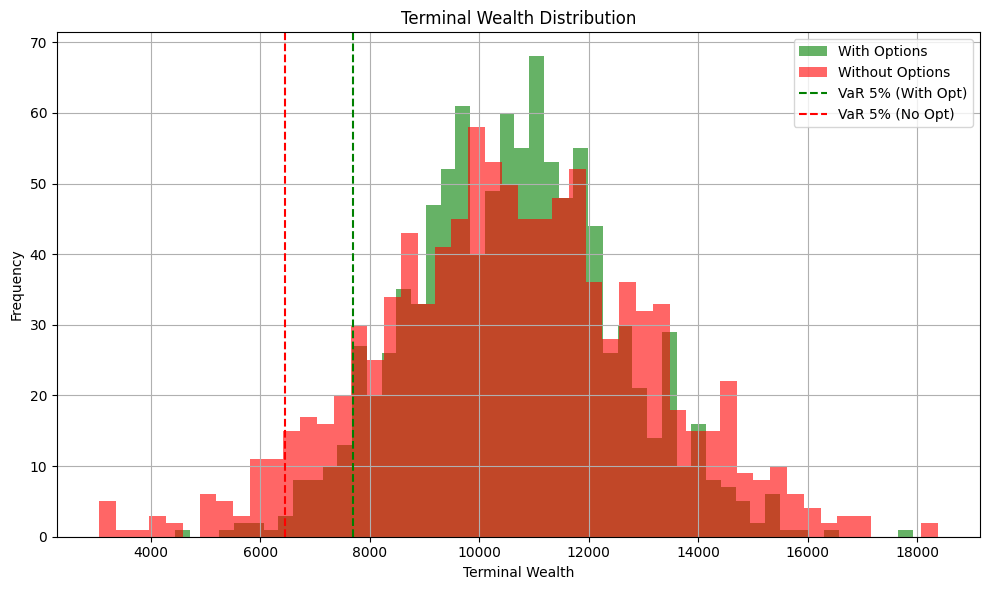

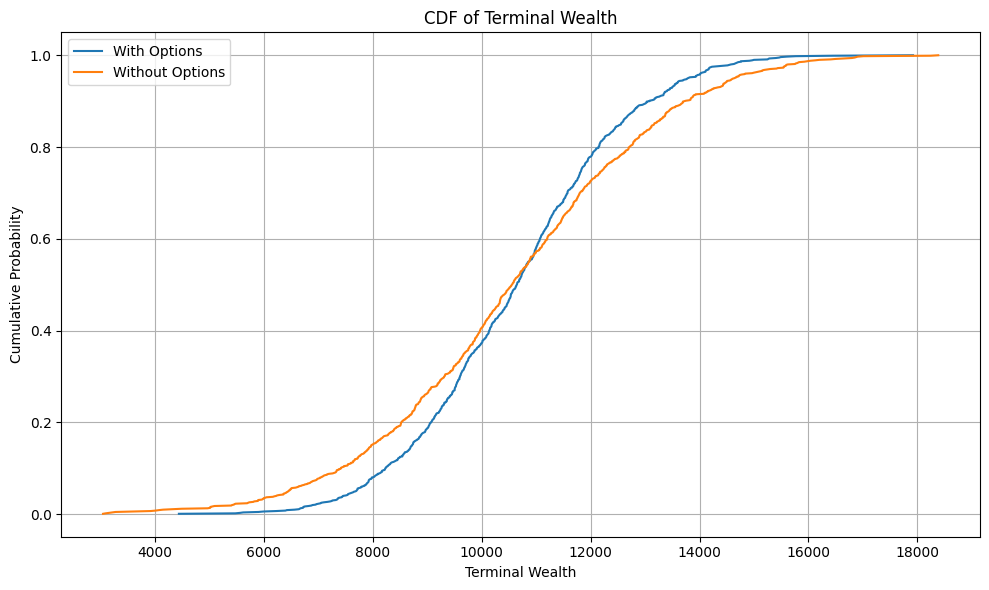

In [ ]:
import pandas as pd

# --- Risk-Neutral Probabilities DataFrame ---
rn_data = []
for nid, node in tree['nodes'].items():
    rn_prob = node.get('risk_neutral_prob', None)
    if rn_prob is not None:
        rn_data.append({
            'Node ID': nid,
            'Stage': node['stage'],
            'Parent': node['parent'],
            'Risk-Neutral Probability': rn_prob,
            'Full Prob (Real-World)': node.get('full_prob', None)
        })
df_rn_probs = pd.DataFrame(rn_data)

# --- Option Prices per Node ---
option_data = []
for nid, node in tree['nodes'].items():
    entry = {
        'Node ID': nid,
        'Stage': node['stage'],
        'Parent': node['parent']
    }
    for k in node:
        if k.startswith('option_') and k.endswith('_value'):
            entry[k] = node[k]
    option_data.append(entry)
df_options = pd.DataFrame(option_data)

# --- Optimization Result Summary ---



# --- Export to Excel ---
with pd.ExcelWriter("portfolio_optimization_results.xlsx") as writer:
    df_rn_probs.to_excel(writer, sheet_name="RiskNeutralProbs", index=False)
    df_options.to_excel(writer, sheet_name="OptionPrices", index=False)

print("\n✅ Export complete: portfolio_optimization_results.xlsx")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Simulate or Load Your Data ===
# Replace these with real terminal wealth arrays if available
np.random.seed(42)
wealth_with_options = np.random.normal(loc=10600, scale=1900, size=1000)
wealth_without_options = np.random.normal(loc=10400, scale=2500, size=1000)

# === Step 2: Risk Metrics Function ===
def risk_metrics(data, label):
    p5 = np.percentile(data, 5)
    cvar_95 = data[data <= p5].mean()
    var_95 = p5
    worst = np.min(data)
    std_dev = np.std(data)

    print(f"{label}:\n"
          f"  VaR@95: {var_95:.2f}\n"
          f"  CVaR@95: {cvar_95:.2f}\n"
          f"  Worst-case: {worst:.2f}\n"
          f"  Std Dev: {std_dev:.2f}\n")

# === Step 3: Print Metrics ===
risk_metrics(wealth_with_options, "With Options")
risk_metrics(wealth_without_options, "Without Options")

# === Step 4: Histogram Comparison ===
plt.figure(figsize=(10, 6))
plt.hist(wealth_with_options, bins=50, alpha=0.6, label='With Options', color='green')
plt.hist(wealth_without_options, bins=50, alpha=0.6, label='Without Options', color='red')
plt.axvline(np.percentile(wealth_with_options, 5), color='green', linestyle='--', label='VaR 5% (With Opt)')
plt.axvline(np.percentile(wealth_without_options, 5), color='red', linestyle='--', label='VaR 5% (No Opt)')
plt.title("Terminal Wealth Distribution")
plt.xlabel("Terminal Wealth")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 5: Cumulative Distribution Function (CDF) ===
plt.figure(figsize=(10, 6))
for data, label in zip([wealth_with_options, wealth_without_options],
                       ['With Options', 'Without Options']):
    sorted_data = np.sort(data)
    p = np.arange(1, len(data)+1) / len(data)
    plt.plot(sorted_data, p, label=label)

plt.title("CDF of Terminal Wealth")
plt.xlabel("Terminal Wealth")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
